In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [17]:
ctype = np.float64

### `init_grid` 
input: `shape`: (shape of a grid) ; `threshold`: density of the living cells 
output: `grid` 2darray of boolean 
initialize a random grid (2darray) of double float of dimension shape (the threshold help to define density)

In [3]:
def init_grid(shape, threshold=0.50):
    """
    initialize a random  grid of double float 
    of dimension shape (the threshold help to define density)
    """
    x = np.zeros(shape,dtype=ctype)
    r = np.random.random(shape)
    x[:,:] = (r> 1.0 - threshold)
    return x

In [4]:
def get_nbneigh(grid, coord):
    irange, jrange = grid.shape
    i, j = coord
    biinf = max(0, i - 1)
    bisup = min(irange - 1, i + 1)
    bjinf = max(0,j - 1)
    bjsup = min(jrange - 1,j + 1)
    nb_neigh = 0
    # loop over neighs to count living cells
    for ii in range(biinf, bisup + 1):
        for jj in range(bjinf, bjsup + 1):
            if grid[ii, jj]:
                nb_neigh = nb_neigh + 1
    # in my count I count current cell itself substract the value
    nb_neigh = nb_neigh-grid[i, j]
    return nb_neigh


### `life_step(grid)` : 
- input: `grid` a 2darray of cells (boolean); 
- output: `res_grid`  2darray ; the state of each cell of `grid` resulting from the application of the rules

In [5]:
def life_step(grid):
    irange, jrange = grid.shape
    res_grid = np.zeros(grid.shape,dtype=ctype)
    for j in range(jrange):
        for i in range(irange):
            # by default cell_state is dead
            cell_state = False
            # loop over neighs to count living cells
            nb_neigh = get_nbneigh(grid,(i,j))
            # if 2 neighbors cell state isn't modified
            if nb_neigh == 2:
                cell_state = grid[i, j]
            # if 3 neighbors cell state is alive
            elif nb_neigh == 3:
                cell_state = 1
            # in other case cell state is dead (default state)
            res_grid[i, j] = cell_state
    return res_grid

### `conway(grid,n)`
From an initial grid, run n iterations of evolution and display the intermediate statistics (number of alive cells)

In [9]:
def conway(grid, n):
    """
    From an initial grid, run n iterations of evolution and display 
    the intermediate statistics (number of alive cells)
    """
    for i in range(n):
        alive = np.sum(grid)
        print(f'alive cells: {alive:.0f}: {alive / grid.size * 100:2.2f}%')
        grid = life_step(grid)
    return grid

### Exemple on a little grid

In [7]:
grid = init_grid((10,10), 0.5)

In [8]:
grid

array([[0., 0., 1., 0., 1., 0., 0., 1., 0., 1.],
       [1., 1., 1., 1., 1., 0., 0., 1., 1., 1.],
       [1., 1., 0., 0., 0., 1., 1., 0., 1., 0.],
       [0., 1., 1., 1., 1., 0., 1., 1., 0., 1.],
       [1., 1., 0., 1., 1., 0., 0., 0., 1., 0.],
       [1., 1., 0., 0., 1., 0., 0., 1., 1., 0.],
       [0., 1., 0., 1., 0., 1., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0., 1., 0., 1., 1., 0.],
       [1., 1., 0., 1., 1., 0., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 0., 1., 0., 1.]])

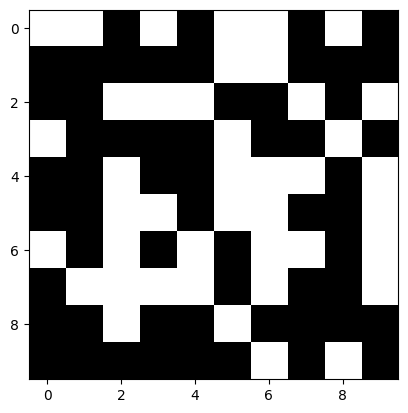

In [9]:
plt.imshow(grid,cmap=plt.cm.binary)

In [10]:
grid0 = grid

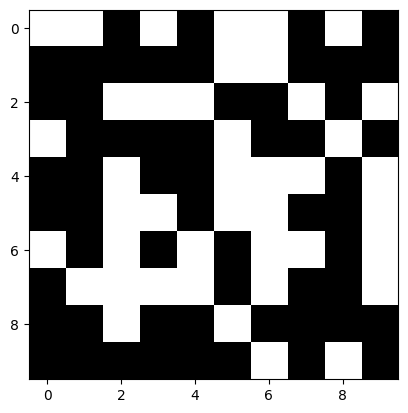

In [11]:
plt.imshow(grid,cmap=plt.cm.binary)

In [12]:
conway(grid0,5)

alive cells: 58: 58.00%
alive cells: 27: 27.00%
alive cells: 21: 21.00%
alive cells: 20: 20.00%
alive cells: 15: 15.00%


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 1., 0., 0.],
       [0., 1., 1., 0., 0., 0., 0., 1., 1., 0.],
       [0., 1., 0., 1., 0., 1., 1., 1., 0., 0.],
       [0., 0., 1., 1., 0., 1., 1., 1., 0., 0.],
       [0., 0., 0., 1., 0., 1., 0., 0., 0., 0.]])

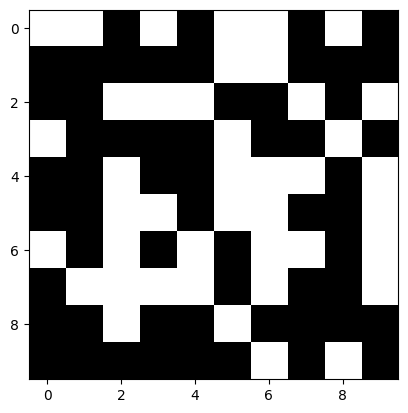

In [13]:
plt.imshow(grid0,cmap=plt.cm.binary)

## `life_step_in`

In [12]:
def life_step_in(grid):
    irange, jrange = grid.shape
    res_grid = np.zeros(grid.shape,dtype=ctype)
    for j in range(jrange):
        for i in range(irange):
            # by default cell_state is dead
            cell_state = 0.
            # loop over neighs to count living cells
            biinf = max(0, i - 1)
            bisup = min(irange - 1, i + 1)
            bjinf = max(0,j - 1)
            bjsup = min(jrange - 1,j + 1)
            nb_neigh = 0
            # loop over neighs to count living cells
            for ii in range(biinf, bisup + 1):
                for jj in range(bjinf, bjsup + 1):
                    nb_neigh = nb_neigh + grid[ii, jj]
            # in my count I count current cell itself substract the value
            nb_neigh = nb_neigh - grid[i, j]
            # if 2 neighbors cell state isn't modified
            if nb_neigh == 2:
                cell_state = grid[i, j]
            # if 3 neighbors cell state is alive
            elif nb_neigh == 3:
                cell_state = 1.0
            # in other case cell state is dead (default state)
            res_grid[i, j] = cell_state
    return res_grid

In [13]:
def conway_in(grid, n):
    """
    From an initial grid, run n iterations of evolution and display 
    the intermediate statistics (number of alive cells)
    """
    for i in range(n):
        alive = np.sum(grid)
        print(f'alive cells: {alive:.0f}: {alive / grid.size * 100:2.2f}%')
        grid = life_step_in(grid)
    return grid

In [16]:
grid_100 = init_grid((10,10), 0.5)
grid_10K = init_grid((100,100), 0.5)
grid_1M  = init_grid((1000,1000), 0.5)
grid_4M  = init_grid((2000,2000), 0.5)

In [17]:
%time life_step_in(grid_100)
%time life_step_in(grid_10K)
%time life_step_in(grid_1M)
%time life_step_in(grid_4M)

CPU times: user 0 ns, sys: 202 μs, total: 202 μs
Wall time: 205 μs
CPU times: user 18.4 ms, sys: 478 μs, total: 18.8 ms
Wall time: 18.7 ms
CPU times: user 1.99 s, sys: 1.86 ms, total: 1.99 s
Wall time: 1.99 s
CPU times: user 8.25 s, sys: 3.84 ms, total: 8.25 s
Wall time: 8.25 s


array([[0., 0., 1., ..., 1., 1., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 0., 0., 1.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 1., ..., 0., 1., 1.]], shape=(2000, 2000))

## Question 1.a
Créer une fonction ```enlarge_grid(grid)``` qui, en fonction d’une grille ```grid```, retourne une grille élargie d’une colonne et d’une ligne de part et d’autre de la grille ```grid```.

In [5]:
def enlarge_grid(grid):
    row,col=grid.shape
    elarg_grid=np.zeros((row+2,col+2))
    elarg_grid[1:row+1,1:col+1]=grid
    return elarg_grid

In [79]:
grid_eg=enlarge_grid(grid)
grid_eg

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 1., 0., 0., 1., 0., 1., 0.],
       [0., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 0.],
       [0., 1., 1., 0., 0., 0., 1., 1., 0., 1., 0., 0.],
       [0., 0., 1., 1., 1., 1., 0., 1., 1., 0., 1., 0.],
       [0., 1., 1., 0., 1., 1., 0., 0., 0., 1., 0., 0.],
       [0., 1., 1., 0., 0., 1., 0., 0., 1., 1., 0., 0.],
       [0., 0., 1., 0., 1., 0., 1., 0., 0., 1., 0., 0.],
       [0., 1., 0., 0., 0., 0., 1., 0., 1., 1., 0., 0.],
       [0., 1., 1., 0., 1., 1., 0., 1., 1., 1., 1., 0.],
       [0., 1., 1., 1., 1., 1., 1., 0., 1., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

## Question 1.b
À partir de ```life_step_in``` créer une fonction ```life_step_eg``` qui applique les règle du jeu de la vie sur une grille élargie. Attention on ne doit pas modifier les valeurs des cellules artificiellement ajoutée au bord. Modifiez ```conway``` pour utiliser cette nouvelle version.

In [14]:
def life_step_eg(grid):
    irange, jrange = grid.shape
    res_grid = np.zeros(grid.shape,dtype=ctype)
    for j in range(1,jrange-1):
        for i in range(1,irange-1):
            # by default cell_state is dead
            cell_state = 0.
            # loop over neighs to count living cells
            nb_neigh = 0
            # loop over neighs to count living cells
            for ii in range(i-1,i + 1):
                for jj in range(j-1, j + 1):
                    nb_neigh = nb_neigh + grid[ii, jj]
            # in my count I count current cell itself substract the value
            nb_neigh = nb_neigh - grid[i, j]
            # if 2 neighbors cell state isn't modified
            if nb_neigh == 2:
                cell_state = grid[i, j]
            # if 3 neighbors cell state is alive
            elif nb_neigh == 3:
                cell_state = 1.0
            # in other case cell state is dead (default state)
            res_grid[i, j] = cell_state
    return res_grid

In [80]:
life_step_eg(grid_eg)

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 1., 0.],
       [0., 0., 1., 1., 0., 0., 0., 0., 0., 1., 1., 0.],
       [0., 0., 1., 1., 0., 0., 0., 1., 1., 0., 0., 0.],
       [0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 1., 0.],
       [0., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [97]:
life_step_in(grid_eg)

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 1., 0., 0., 1., 0., 1., 0.],
       [0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 1., 1., 1., 0.],
       [0., 0., 1., 1., 0., 0., 1., 0., 0., 0., 1., 0.],
       [0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 1., 0., 0., 0., 0., 1., 0., 1., 0., 1., 0.],
       [0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.]])

In [15]:
def conway_eg(grid, n):
    """
    From an initial grid, run n iterations of evolution and display 
    the intermediate statistics (number of alive cells)
    """
    for i in range(n):
        alive = np.sum(grid)
        print(f'alive cells: {alive:.0f}: {alive / grid.size * 100:2.2f}%')
        grid = life_step_eg(grid)
    return grid

In [ ]:
conway_eg(grid_eg,3)

alive cells: 58: 40.28%
alive cells: 35: 24.31%
alive cells: 13: 9.03%


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

## Question 1.c
Réaliser de nouvelles mesures de performance et de nouveaux profilages. Quels impacts sur les performances du code ?

In [90]:
%time life_step_eg(grid_100)
%time life_step_eg(grid_10K)
%time life_step_eg(grid_1M)
%time life_step_eg(grid_4M)

CPU times: user 78 μs, sys: 2 μs, total: 80 μs
Wall time: 82.7 μs
CPU times: user 8.75 ms, sys: 0 ns, total: 8.75 ms
Wall time: 8.76 ms
CPU times: user 952 ms, sys: 1.86 ms, total: 954 ms
Wall time: 953 ms
CPU times: user 3.86 s, sys: 0 ns, total: 3.86 s
Wall time: 3.86 s


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 1., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 1., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(2000, 2000))

# <font color='green'>Les performance se sont largement améliorierées . c'est qu'on attendait vu qu'on a enlevé des instructions</font>

## Question 2.a
sur la base de ```life_step_eg``` une fonction ```life_step_unroll``` qui calcule explicitement nbneigh sans la double boucle interne.

In [ ]:
def life_step_ur(grid):
    irange, jrange = grid.shape
    res_grid = np.zeros(grid.shape,dtype=ctype)
    for j in range(1,jrange-1):
        for i in range(1,irange-1):
            # by default cell_state is dead
            cell_state = 0
            # loop over neighs to count living cells
            nb_neigh = 0
            # neighs to count living cells without loop
            nb_neigh=np.sum(grid[i-1:i + 1,j-1j + 1])
            # in my count I count current cell itself substract the value
            nb_neigh = nb_neigh - grid[i, j]
            # if 2 neighbors cell state isn't modified
            if nb_neigh == 2:
                cell_state = grid[i, j]
            # if 3 neighbors cell state is alive
            elif nb_neigh == 3:
                cell_state = 1.0
            # in other case cell state is dead (default state)
            res_grid[i, j] = cell_state
    return res_grid

In [98]:
eg=life_step_eg(grid_eg)
ur=life_step_ur(grid_eg)

In [100]:
np.all(eg==ur)

np.True_

# <font color='green'> Meme resultat</font>

## Question 2.b
Réaliser de nouvelles mesures de performance et de nouveaux profilages. Quels impacts sur les performances du code ?

In [101]:
%time life_step_ur(grid_100)
%time life_step_ur(grid_10K)
%time life_step_ur(grid_1M)
%time life_step_ur(grid_4M)

CPU times: user 212 μs, sys: 4 μs, total: 216 μs
Wall time: 219 μs
CPU times: user 25 ms, sys: 984 μs, total: 26 ms
Wall time: 25.5 ms
CPU times: user 2.46 s, sys: 825 μs, total: 2.46 s
Wall time: 2.46 s
CPU times: user 10 s, sys: 1.44 ms, total: 10 s
Wall time: 10 s


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 1., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 1., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(2000, 2000))

## Question 3.a
Sur la base de ```life_step_unroll``` écrire une fonction ```life_step_store``` qui réutilise les sommes partielles déjà calculées.

In [ ]:
def life_step_st(grid):
    #TODO

## Question 3.b
Réaliser de nouvelles mesures de performance et de nouveaux profilages. Quels impacts sur les performances du code ?

In [1]:
import numpy as np
g=np.array([[0.,0.,1.,0.,0.,1.,0.,0.,1.,1.],
 [1.,1.,1.,0.,0.,0.,1.,0.,0.,1.],
 [1.,1.,1.,1.,1.,1.,1.,0.,1.,1.],
 [0.,1.,1.,0.,0.,0.,0.,0.,1.,1.],
 [1.,1.,0.,0.,0.,0.,0.,0.,1.,0.],
 [1.,1.,1.,1.,1.,1.,0.,1.,1.,0.],
 [1.,1.,0.,0.,1.,0.,1.,0.,0.,0.],
 [1.,0.,1.,0.,1.,1.,1.,1.,0.,1.],
 [1.,1.,0.,1.,0.,1.,0.,0.,0.,0.],
 [0.,0.,0.,1.,1.,1.,1.,0.,1.,0.]])


In [2]:
gg=enlarge_grid(g)


NameError: name 'enlarge_grid' is not defined

In [32]:
conway_eg(gg,10)[1:-1,1:-1]

alive cells: 53: 36.81%
alive cells: 31: 21.53%
alive cells: 15: 10.42%
alive cells: 7: 4.86%
alive cells: 1: 0.69%
alive cells: 0: 0.00%
alive cells: 0: 0.00%
alive cells: 0: 0.00%
alive cells: 0: 0.00%
alive cells: 0: 0.00%


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])